In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape)
print(matches.columns.tolist())
print("---")
print(deliveries.columns.tolist())

(1095, 20)
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
---
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


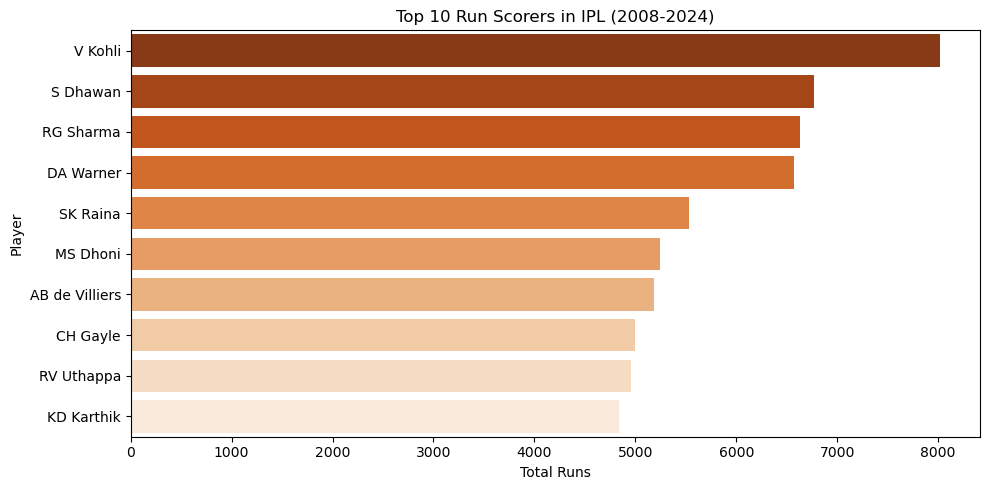

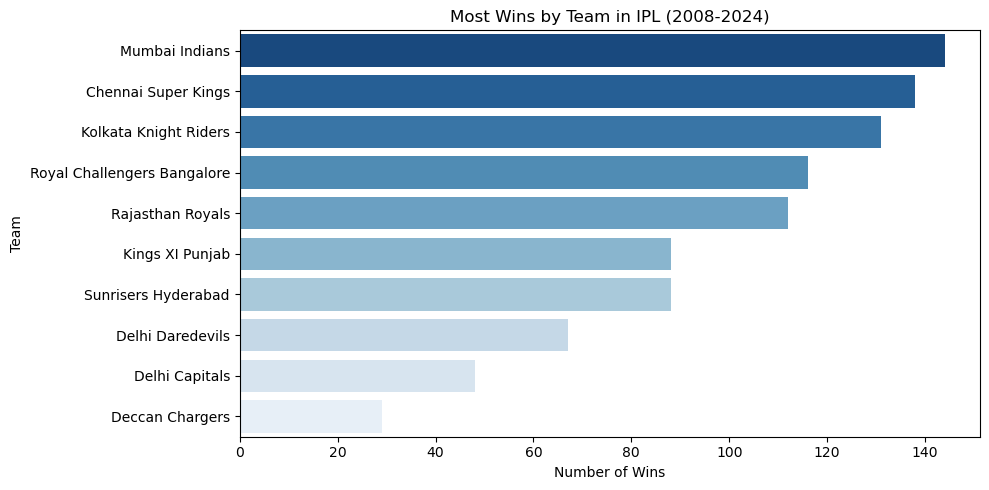

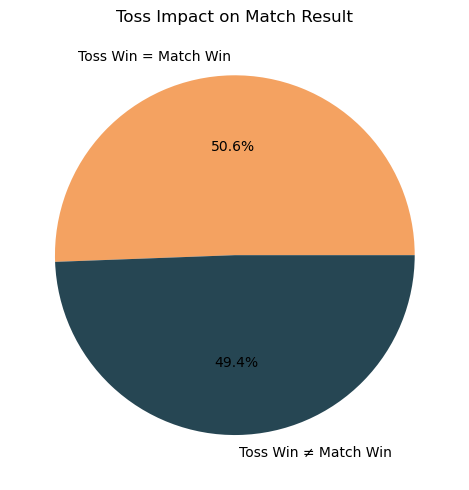

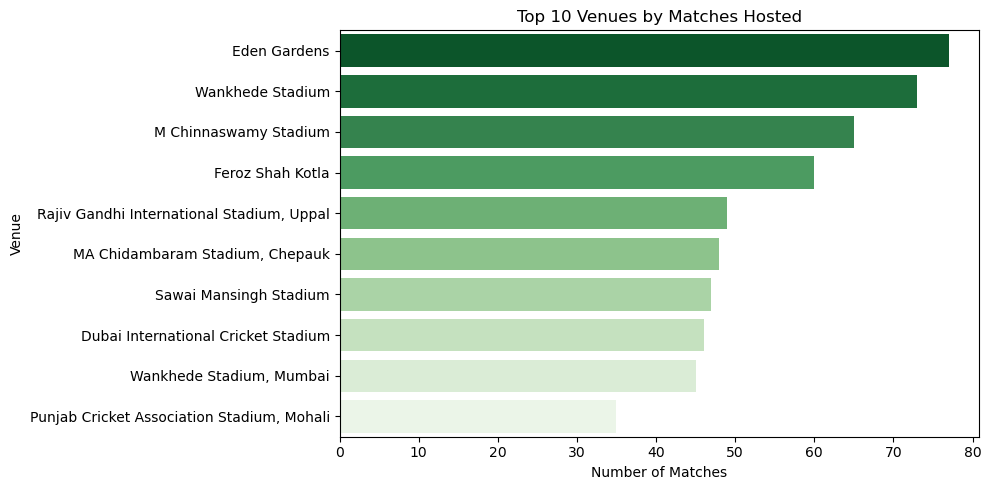

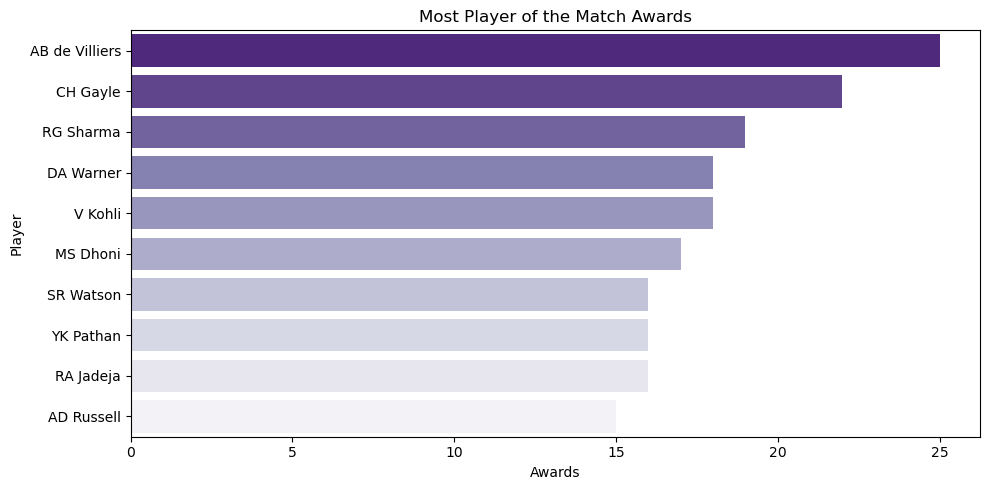

✅ All charts saved!


In [3]:
# ── 1. TOP 10 RUN SCORERS ──────────────────────────────────────────
top_scorers = (deliveries.groupby('batter')['batsman_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10))

plt.figure(figsize=(10,5))
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='Oranges_r')
plt.title('Top 10 Run Scorers in IPL (2008-2024)')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('top_scorers.png')
plt.show()

# ── 2. MOST WINS BY TEAM ───────────────────────────────────────────
team_wins = matches['winner'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=team_wins.values, y=team_wins.index, palette='Blues_r')
plt.title('Most Wins by Team in IPL (2008-2024)')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('team_wins.png')
plt.show()

# ── 3. TOSS IMPACT ────────────────────────────────────────────────
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_won_match'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(toss_impact.values, labels=['Toss Win = Match Win', 'Toss Win ≠ Match Win'],
        autopct='%1.1f%%', colors=['#f4a261','#264653'])
plt.title('Toss Impact on Match Result')
plt.tight_layout()
plt.savefig('toss_impact.png')
plt.show()

# ── 4. TOP VENUES BY MATCHES HOSTED ───────────────────────────────
venue_counts = matches['venue'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=venue_counts.values, y=venue_counts.index, palette='Greens_r')
plt.title('Top 10 Venues by Matches Hosted')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.savefig('venue_analysis.png')
plt.show()

# ── 5. PLAYER OF THE MATCH ────────────────────────────────────────
potm = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=potm.values, y=potm.index, palette='Purples_r')
plt.title('Most Player of the Match Awards')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('potm.png')
plt.show()

print("✅ All charts saved!")

✅ Model Accuracy: 47.71%
              precision    recall  f1-score   support

           0       0.68      0.62      0.65        37
           1       0.50      1.00      0.67         2
           2       0.20      0.14      0.17         7
           3       0.46      0.46      0.46        13
           4       0.50      0.40      0.44         5
           5       0.33      0.11      0.17         9
           6       0.37      0.41      0.39        17
           7       0.00      0.00      0.00         2
           8       0.50      0.52      0.51        23
           9       0.40      0.67      0.50         3
          10       0.50      0.54      0.52        26
          11       0.33      0.33      0.33         3
          12       0.00      0.00      0.00         3
          13       0.56      0.56      0.56        25
          14       0.50      0.25      0.33         4
          16       0.37      0.38      0.38        26
          17       0.00      0.00      0.00         2
  

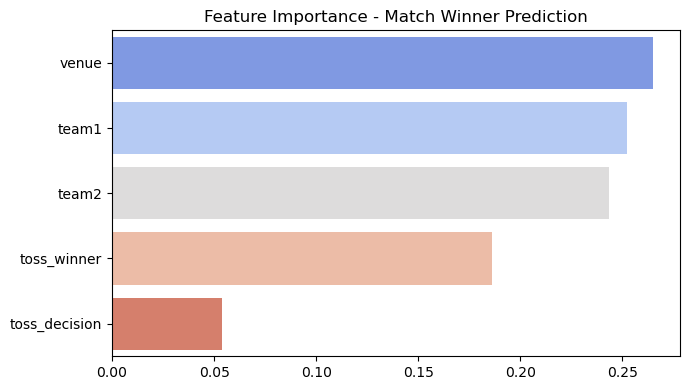

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ── PREPARE DATA ──────────────────────────────────────────────────
df = matches[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']].dropna()

# Label encode all columns
le = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']]
y = df_encoded['winner']

# ── TRAIN ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ── EVALUATE ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred, zero_division=0))

# ── FEATURE IMPORTANCE ────────────────────────────────────────────
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='coolwarm')
plt.title('Feature Importance - Match Winner Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [5]:
git init

git add .

git commit -m "IPL Match Intelligence Dashboard - EDA + ML"

SyntaxError: invalid syntax (1515823235.py, line 1)